In [1]:
import os
import sys
sys.path.append('./coeqwalpackage')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from coeqwalpackage.metrics import percent_change_from_baseline
from coeqwalpackage import cqwlutils as cu
from coeqwalpackage.plotting import (custom_parallel_coordinates_highlight_scenarios, custom_parallel_coordinates_highlight_scenarios_baseline_at_zero)

In [2]:
CtrlFile = 'CalSim3DataExtractionInitFile_v4.xlsx'
CtrlTab = 'Init'
_, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, GroupDataDirPath, ScenarioDir, *_ = cu.read_init_file(CtrlFile, CtrlTab)

metrics_path = os.path.join(GroupDataDirPath, "metrics_output", "all_metrics_output.csv")
df = pd.read_csv(metrics_path, index_col=0)
df.index.name = 'Scenario'
print(f"Metrics: {df.shape[0]} scenarios, {df.shape[1]} columns")

tiers_base = os.path.join(ScenarioDir, "Performance_Metrics", "Tiered_Outcome_Measures")

flood_df = pd.read_csv(os.path.join(tiers_base, "Reservoir_FloodRisk", "tier_assignment_output.csv"), index_col='Scenario')
flood_tiers = flood_df[[c for c in flood_df.columns if 'FloodTier' in c]]

storage_df = pd.read_csv(os.path.join(tiers_base, "Reservoir_Storage", "tier_assignment_output.csv"), index_col='Scenario')
storage_tiers = storage_df[[c for c in storage_df.columns if 'Storage_Tier' in c]]

sal_indelta = pd.read_csv(os.path.join(tiers_base, "Salinity", "InDeltaTierAssignment.csv"), index_col=0)
sal_indelta.columns = ['Salinity_InDelta_Tier']

sal_export = pd.read_csv(os.path.join(tiers_base, "Salinity", "ExportTierAssignment.csv"), index_col=0)
sal_export.columns = ['Salinity_Export_Tier']
sal_tiers = pd.concat([sal_indelta, sal_export], axis=1)

gw_tiers = pd.read_csv(os.path.join(tiers_base, "Groundwater", "Data", "GroundWater_Tiers.csv"), index_col='scenario')
gw_tiers.columns = ['GW_' + c + '_Tier' for c in gw_tiers.columns]

tiers_df = pd.concat([flood_tiers, storage_tiers, sal_tiers, gw_tiers], axis=1, join='outer').sort_index()
print(f"Tiers: {tiers_df.shape[0]} scenarios, {tiers_df.shape[1]} columns")

OUT_DIR = os.path.join(GroupDataDirPath, "metrics_output", "new_plotting")
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Saving to: {OUT_DIR}")

Metrics: 35 scenarios, 87 columns
Tiers: 36 scenarios, 60 columns
Saving to: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting


In [10]:
FIGSIZE = (20, 7)

SCENARIO_SETS = [
    {"name": "s20_vs_s47_s56", "baseline": 20, "compare": [47, 56]},
    {"name": "s27_vs_s62_s63", "baseline": 27, "compare": [62, 63]}]

for s in SCENARIO_SETS:
    s["baseline_id"] = f's{s["baseline"]:04d}'
    s["compare_ids"] = [f's{c:04d}' for c in s["compare"]]
    s["all_ids"] = [s["baseline_id"]] + s["compare_ids"]
    s["colors"] = ['black', 'red', 'blue', 'green'][:len(s["all_ids"])]
    s["labels"] = [f'{s["baseline_id"]} (Baseline)'] + s["compare_ids"]

METRIC_GROUPS = {
    'Storage_Apr': [c for c in df.columns if c.startswith('Apr') and 'S_' in c and 'TAF' in c],
    'Deliveries': [c for c in df.columns if 'DEL_' in c],
    'Salinity_X2': [c for c in df.columns if 'X2_' in c or 'EC_' in c]}
METRIC_GROUPS = {k: v for k, v in METRIC_GROUPS.items() if v}

TIER_GROUPS = {
    'Tier_FloodRisk': [c for c in tiers_df.columns if 'FloodTier' in c],
    'Tier_Storage': [c for c in tiers_df.columns if 'Storage_Tier' in c],
    'Tier_Salinity': [c for c in tiers_df.columns if 'Salinity' in c],
    'Tier_GW': [c for c in tiers_df.columns if 'GW_' in c]}

TIER_GROUPS = {k: v for k, v in TIER_GROUPS.items() if v}

def short_label(c):
    for p in ['Apr_Avg_', 'Sep_Avg_', 'Ann_Avg_', 'Fall_Ann_Avg_', 'Spring_Ann_Avg_', 
              '_TAF', '_CFS', '_KM', '_UMHOS/CM', '_FloodTier', '_Storage_Tier', '_Tier', 'GW_', 'S_']:
        c = c.replace(p, '')
    return c

for k, v in METRIC_GROUPS.items():
    print(f"{k}: {len(v)} cols")

for k, v in TIER_GROUPS.items():
    print(f"{k}: {len(v)} cols")

Storage_Apr: 10 cols
Deliveries: 7 cols
Salinity_X2: 12 cols
Tier_FloodRisk: 8 cols
Tier_Storage: 8 cols
Tier_Salinity: 2 cols
Tier_GW: 42 cols


## 1. Parallel Line Plots

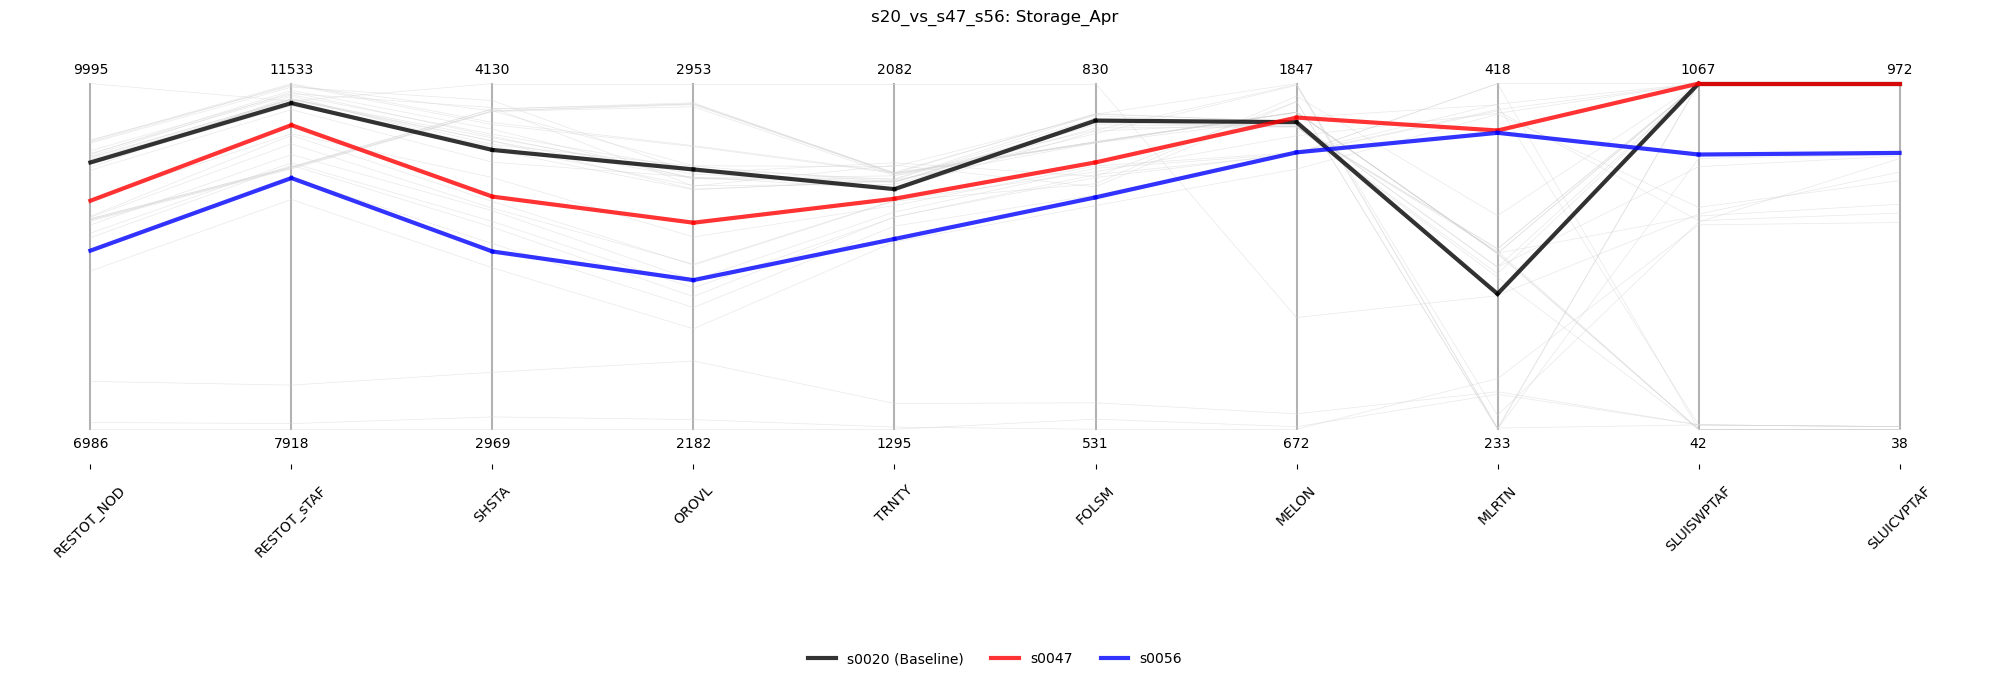

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_s20_vs_s47_s56_Storage_Apr.png


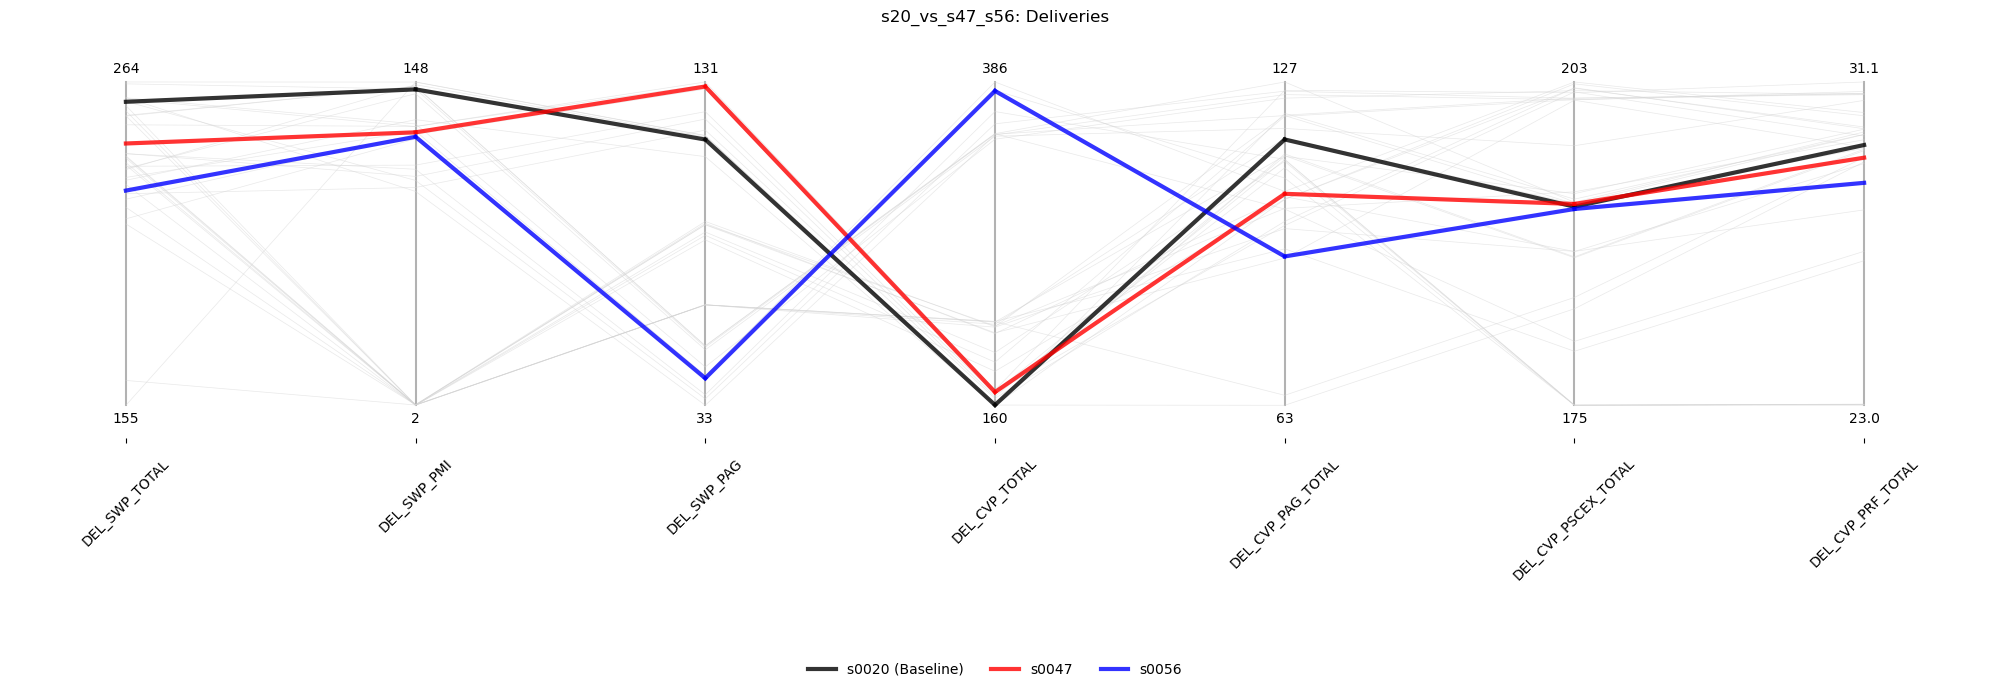

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_s20_vs_s47_s56_Deliveries.png


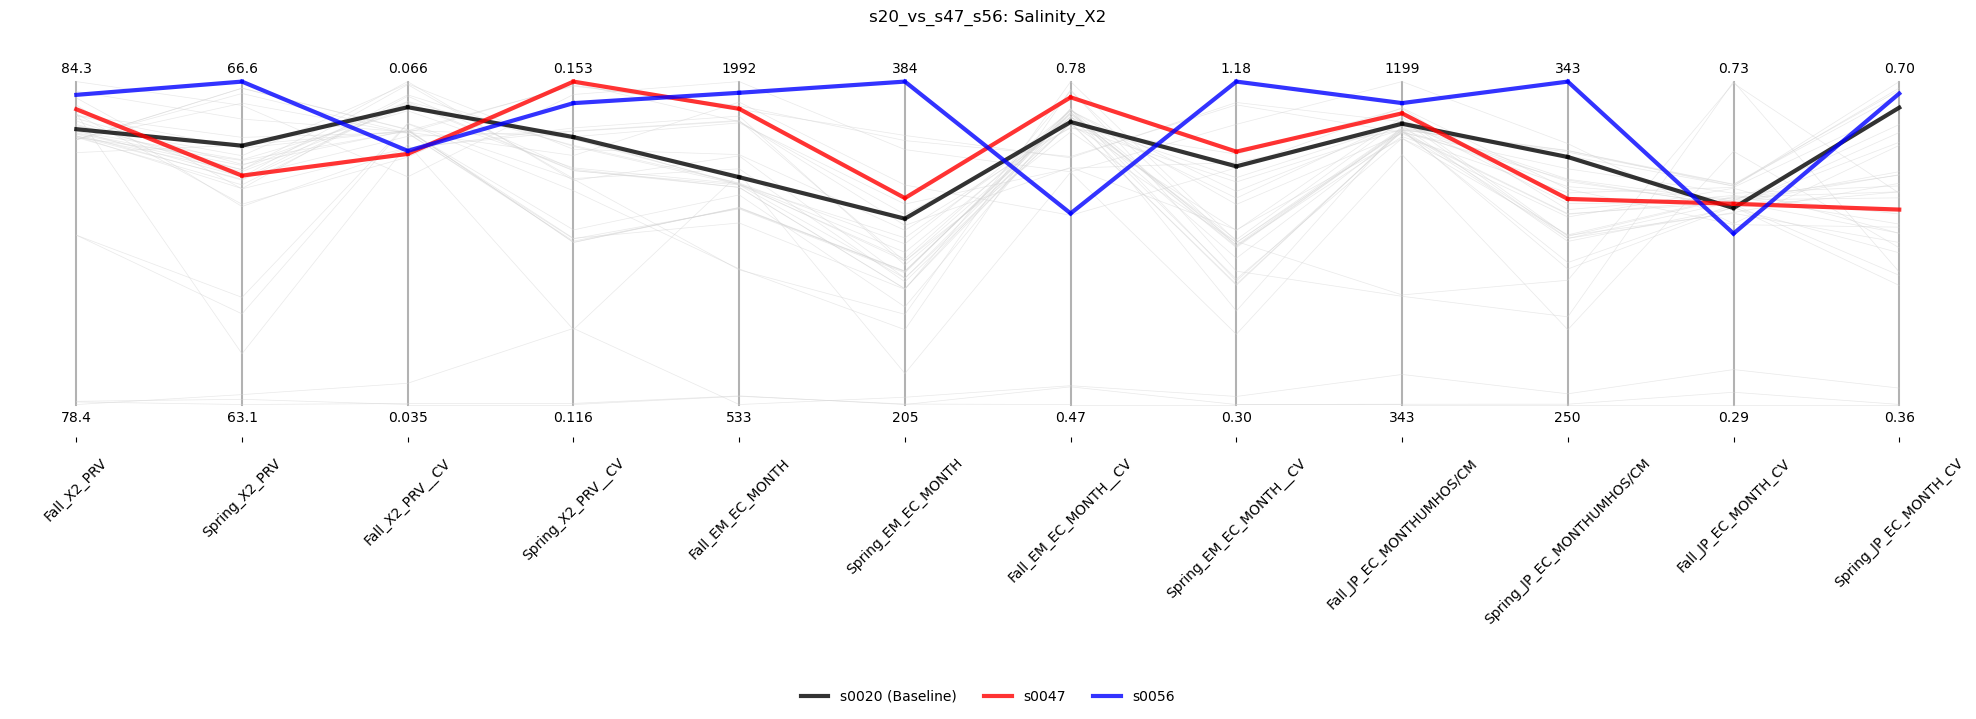

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_s20_vs_s47_s56_Salinity_X2.png


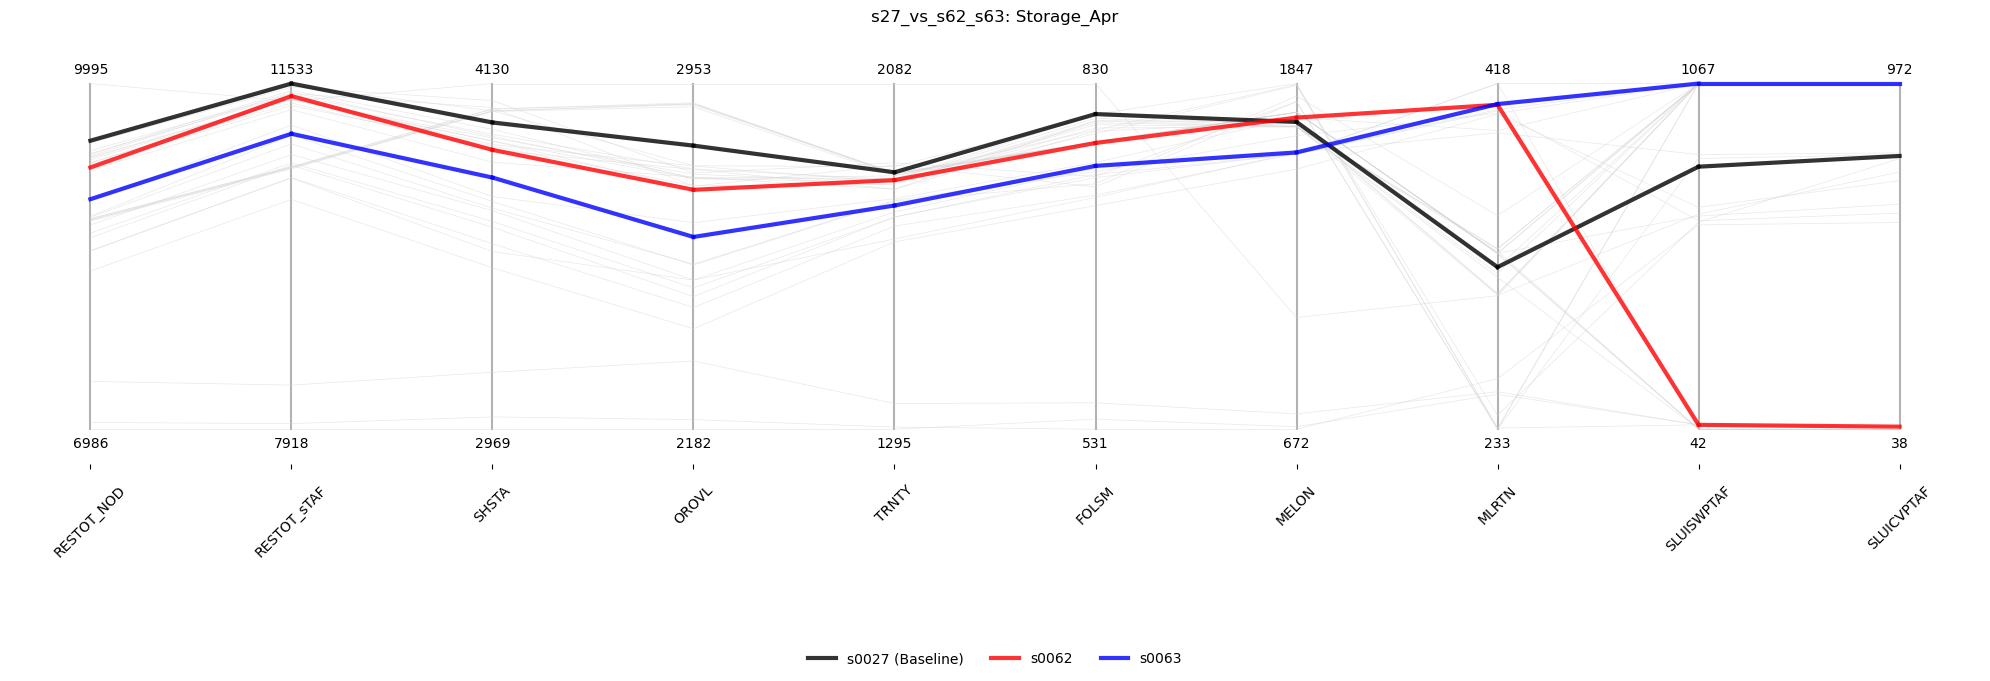

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_s27_vs_s62_s63_Storage_Apr.png


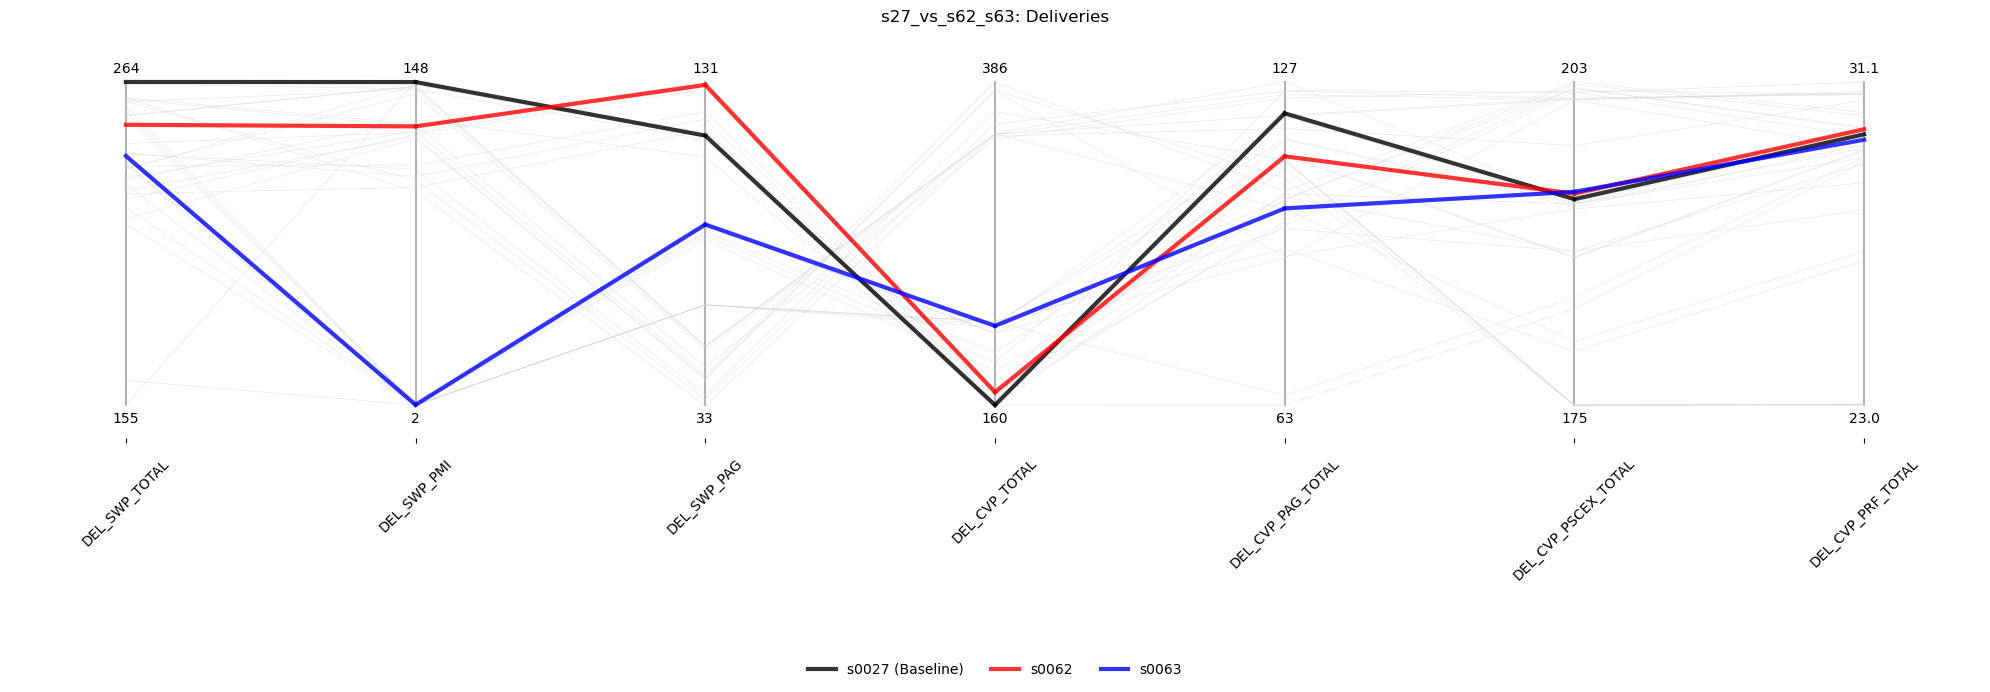

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_s27_vs_s62_s63_Deliveries.png


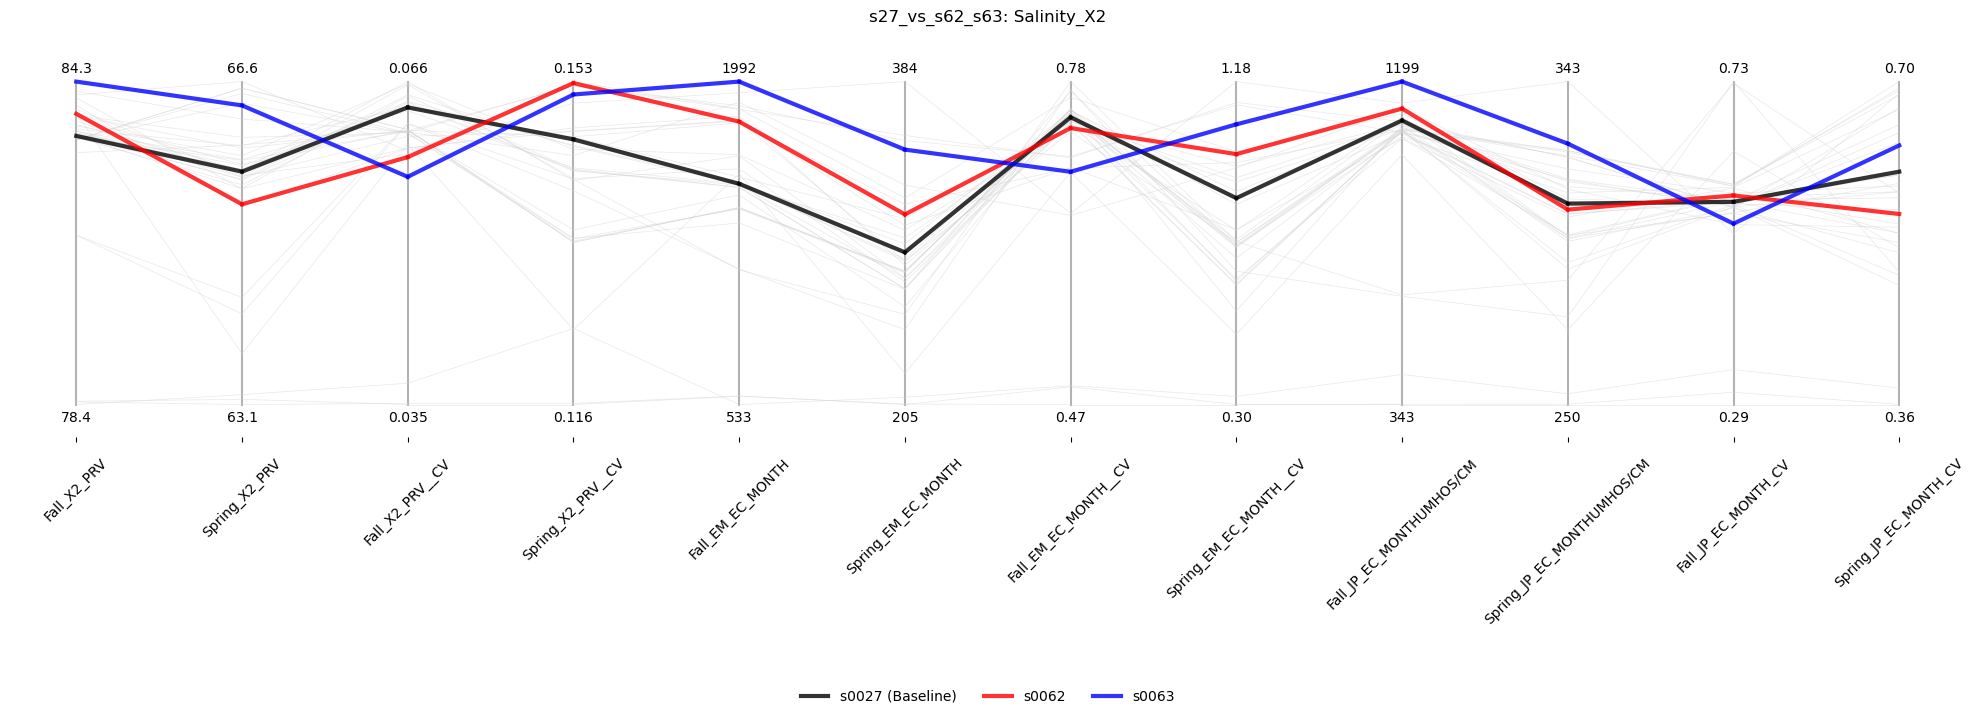

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_s27_vs_s62_s63_Salinity_X2.png


In [4]:
for sset in SCENARIO_SETS:    
    for grp, cols in METRIC_GROUPS.items():
        labels = [short_label(c) for c in cols]
        ideal = 'bottom' if 'Salinity' in grp else 'top'
        minmax = ['min'] * len(cols) if 'Salinity' in grp else ['max'] * len(cols)
        
        save_path = os.path.join(OUT_DIR, f"parallel_{sset['name']}_{grp}.png")
        custom_parallel_coordinates_highlight_scenarios(
            objs=df[cols], columns_axes=cols, axis_labels=labels,
            ideal_direction=ideal, minmaxs=minmax,
            highlight_indices=sset['all_ids'], highlight_colors=sset['colors'],
            highlight_descriptions=sset['labels'],
            title=f"{sset['name']}: {grp}", fontsize=10, figsize=FIGSIZE,
            save_fig_filename=save_path)
        plt.show()
        print(f"Saved: {save_path}")

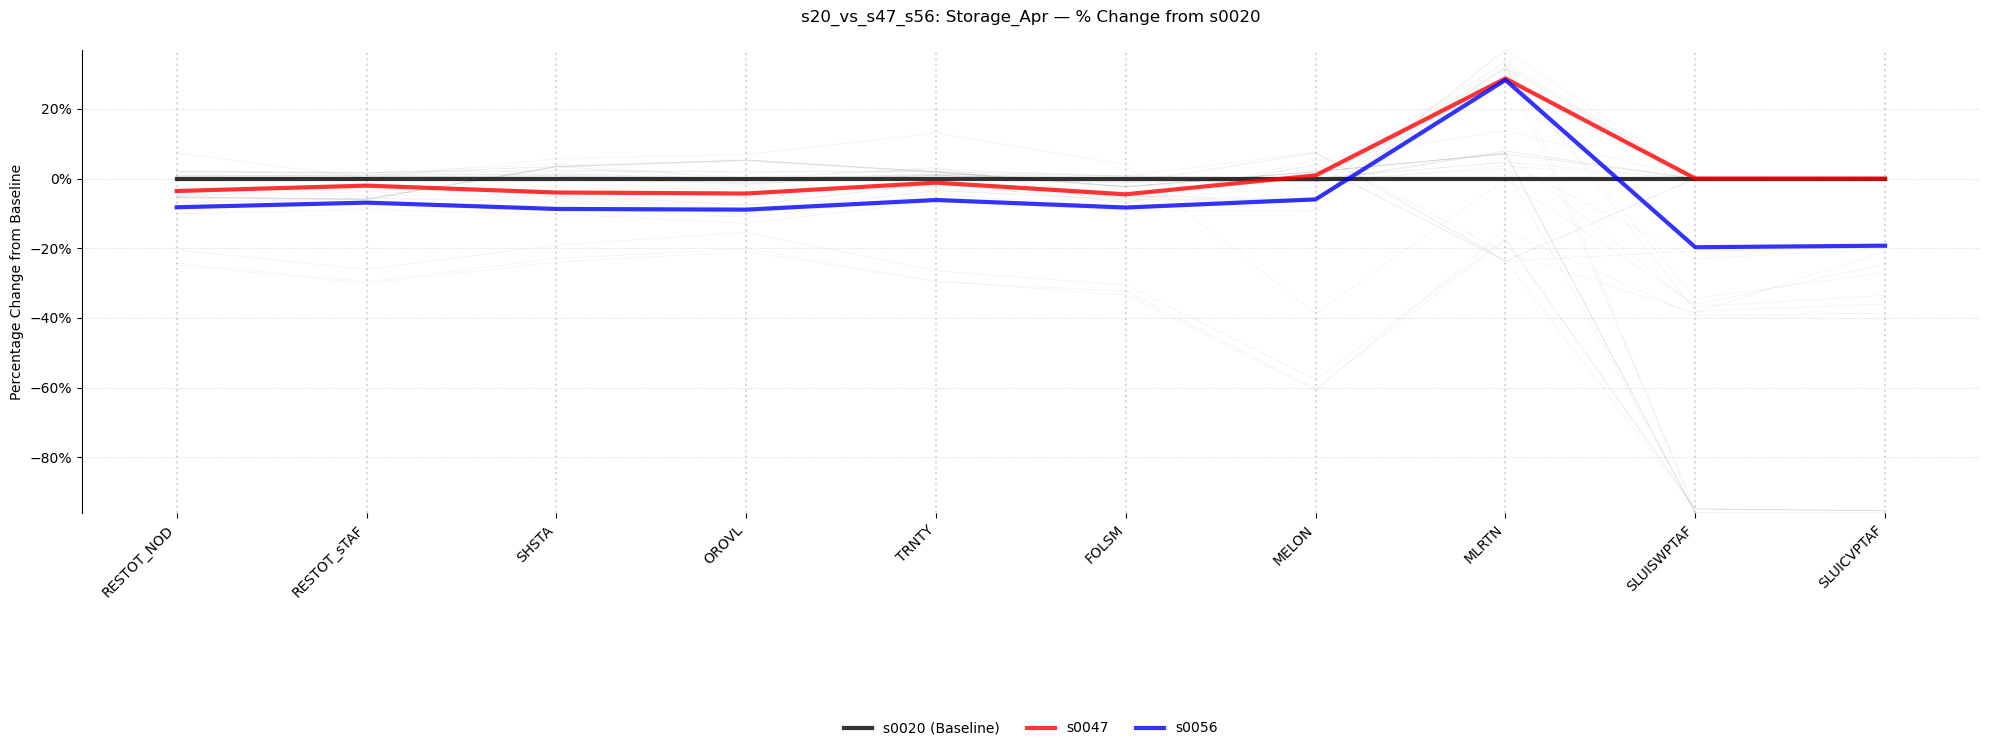

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_pct_s20_vs_s47_s56_Storage_Apr.png


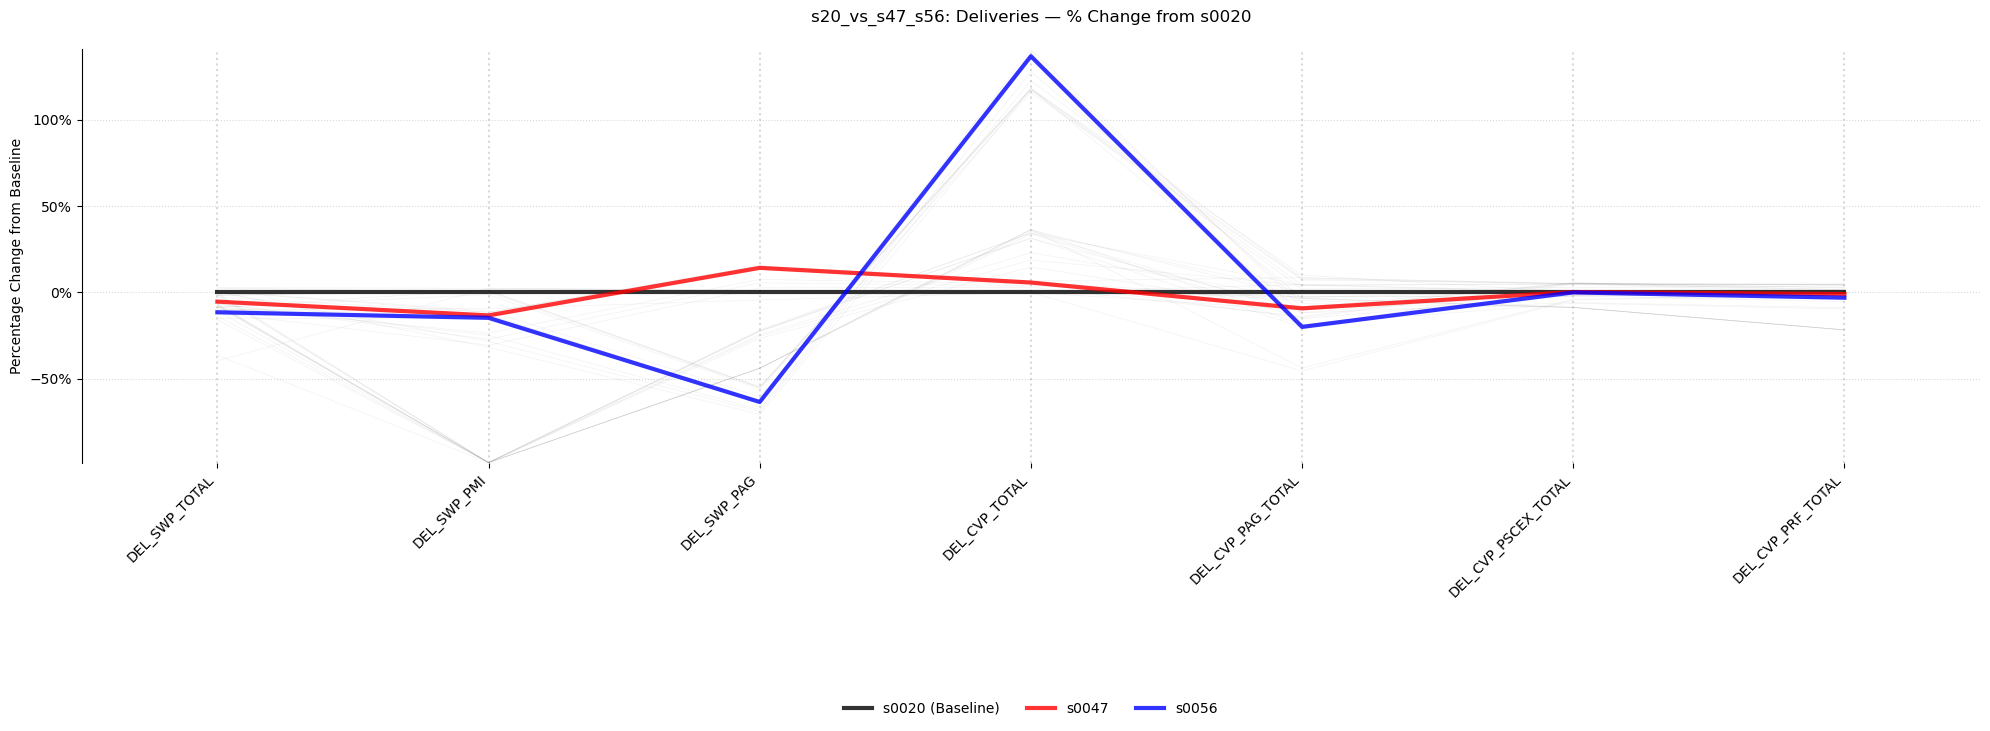

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_pct_s20_vs_s47_s56_Deliveries.png


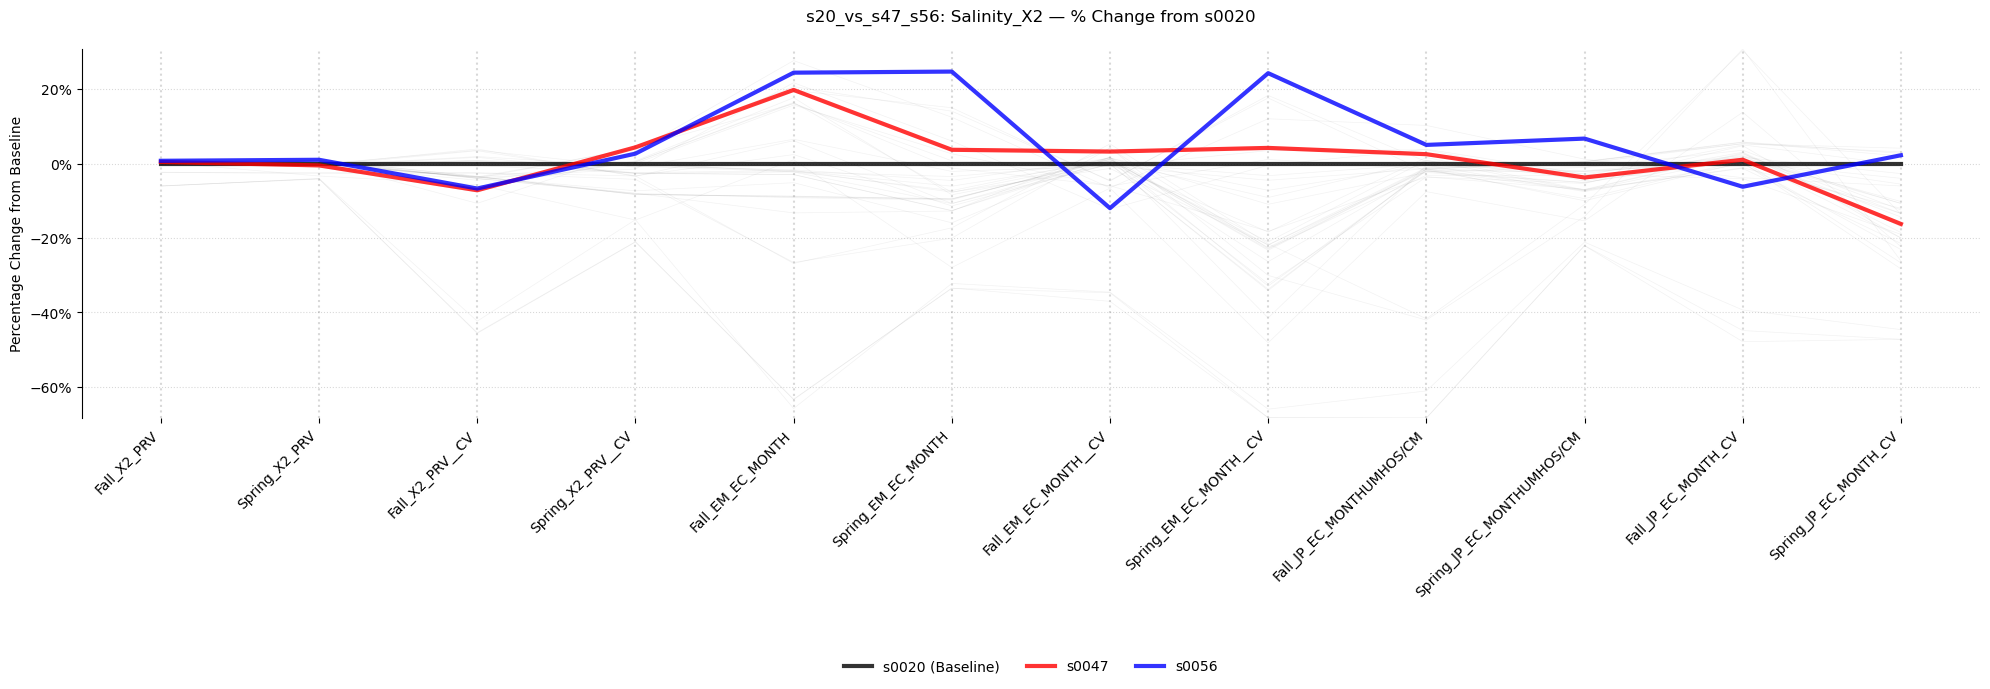

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_pct_s20_vs_s47_s56_Salinity_X2.png


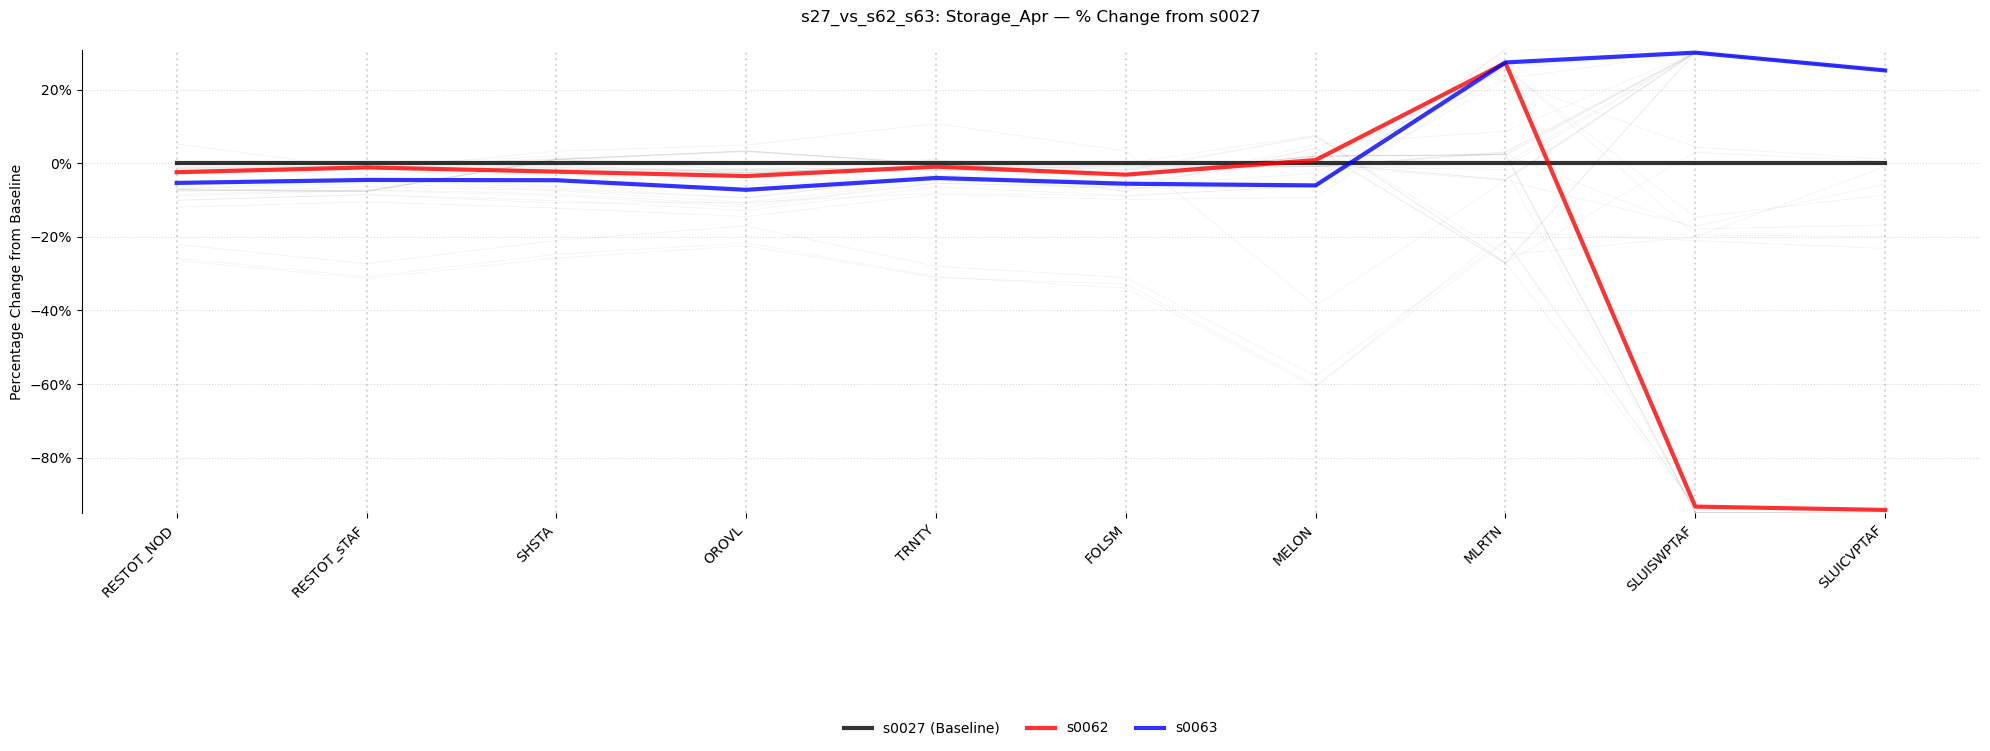

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_pct_s27_vs_s62_s63_Storage_Apr.png


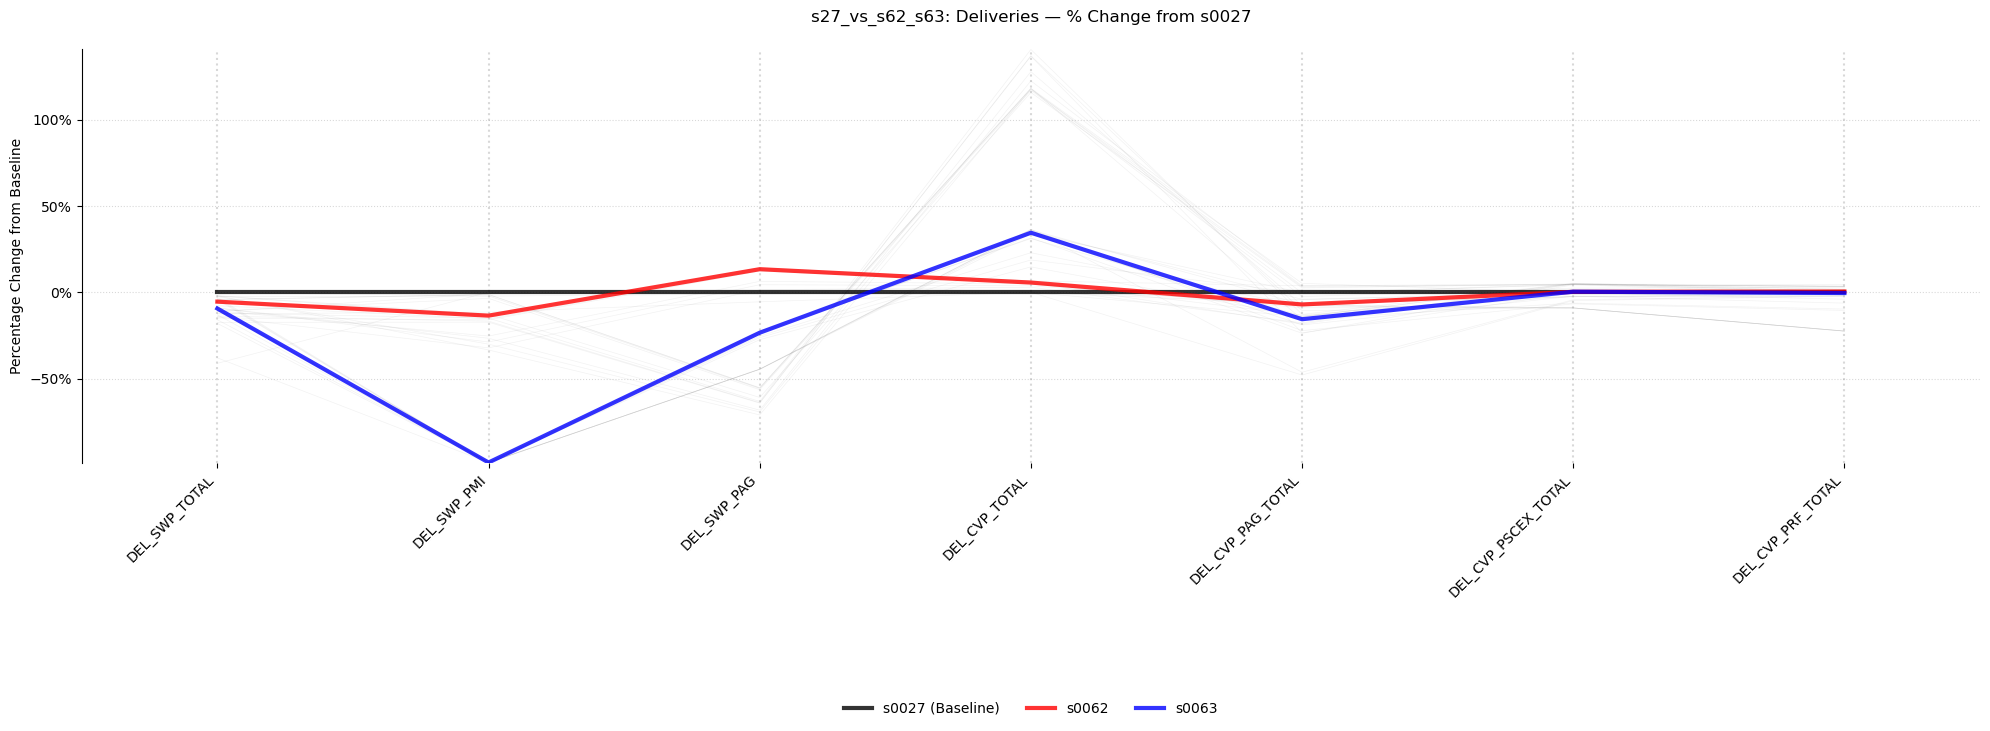

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_pct_s27_vs_s62_s63_Deliveries.png


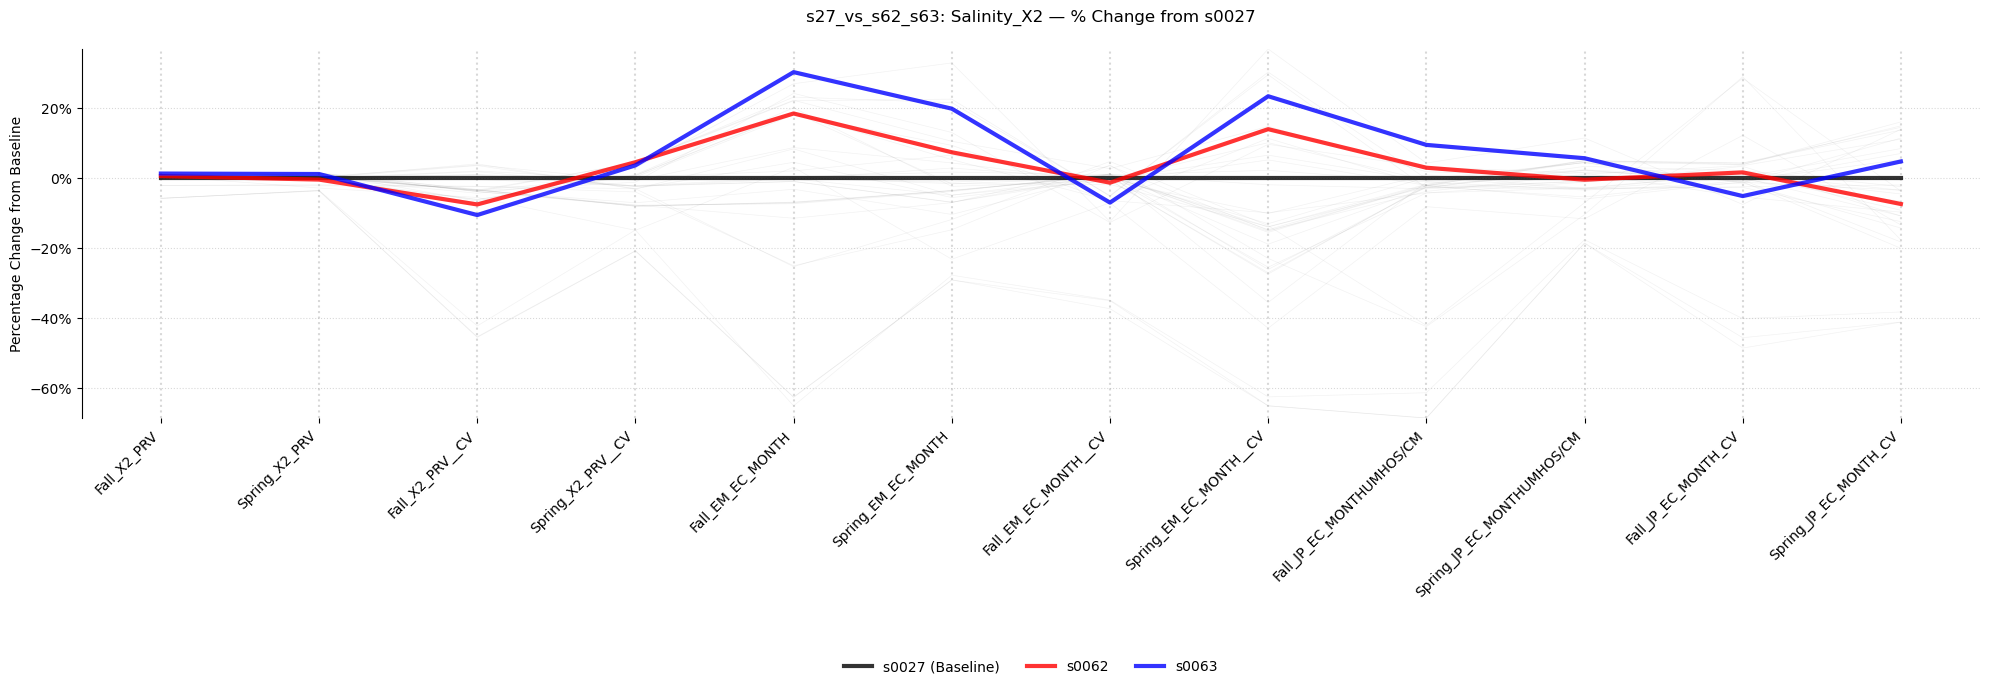

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/parallel_pct_s27_vs_s62_s63_Salinity_X2.png


In [5]:
for sset in SCENARIO_SETS:
    for grp, cols in METRIC_GROUPS.items():
        if sset['baseline_id'] not in df.index:
            print(f"Baseline {sset['baseline_id']} not found")
            continue
        
        pct_df = percent_change_from_baseline(df[cols], sset['baseline_id'])
        labels = [short_label(c) for c in cols]
        
        save_path = os.path.join(OUT_DIR, f"parallel_pct_{sset['name']}_{grp}.png")
        custom_parallel_coordinates_highlight_scenarios_baseline_at_zero(
            objs=pct_df, columns_axes=cols, axis_labels=labels,
            highlight_indices=sset['all_ids'], highlight_colors=sset['colors'],
            highlight_descriptions=sset['labels'],
            title=f"{sset['name']}: {grp} — % Change from {sset['baseline_id']}",
            fontsize=10, figsize=FIGSIZE,
            save_fig_filename=save_path)
        plt.show()
        print(f"Saved: {save_path}")

## 2. Spider/Radar Plots

In [6]:
def plot_radar(df, cols, scenarios, colors, labels, title, save_path=None):
    scenarios = [s for s in scenarios if s in df.index]
    cols = [c for c in cols if c in df.columns]
    if len(scenarios) < 2 or len(cols) < 3:
        print(f"Skip {title}: insufficient data")
        return
    
    data = df.loc[scenarios, cols]
    norm = (data - df[cols].min()) / (df[cols].max() - df[cols].min() + 1e-9)
    
    angles = np.linspace(0, 2*np.pi, len(cols), endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(11, 9), subplot_kw=dict(polar=True))
    
    for i, sc in enumerate(scenarios):
        norm_vals = norm.loc[sc].values.tolist() + [norm.loc[sc].values[0]]
        actual_vals = data.loc[sc].values
        ax.plot(angles, norm_vals, 'o-', lw=2, color=colors[i], label=labels[i])
        ax.fill(angles, norm_vals, alpha=0.1, color=colors[i])
        
        for j, (angle, nv, av) in enumerate(zip(angles[:-1], norm_vals[:-1], actual_vals)):
            txt = f"{av:.0f}" if abs(av) >= 10 else f"{av:.1f}"
            offset = 0.08
            ax.annotate(txt, xy=(angle, nv + offset), fontsize=7, color=colors[i],
                       ha='center', va='bottom', alpha=0.85)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([short_label(c) for c in cols], fontsize=8)
    ax.set_ylim(0, 1.25)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)  # percentile of range
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))
    ax.set_title(title, fontsize=12, pad=15)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/radar_s20_vs_s47_s56_Storage_Apr.png


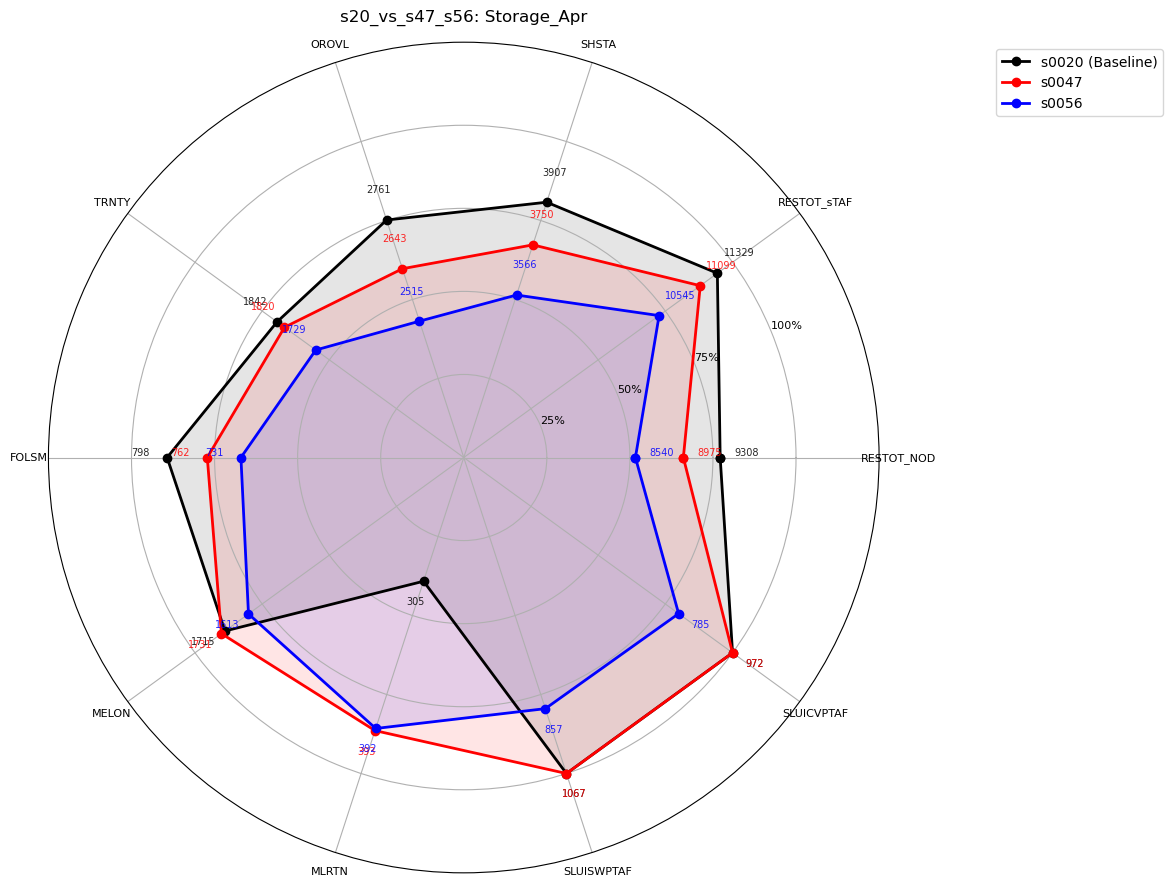

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/radar_s20_vs_s47_s56_Deliveries.png


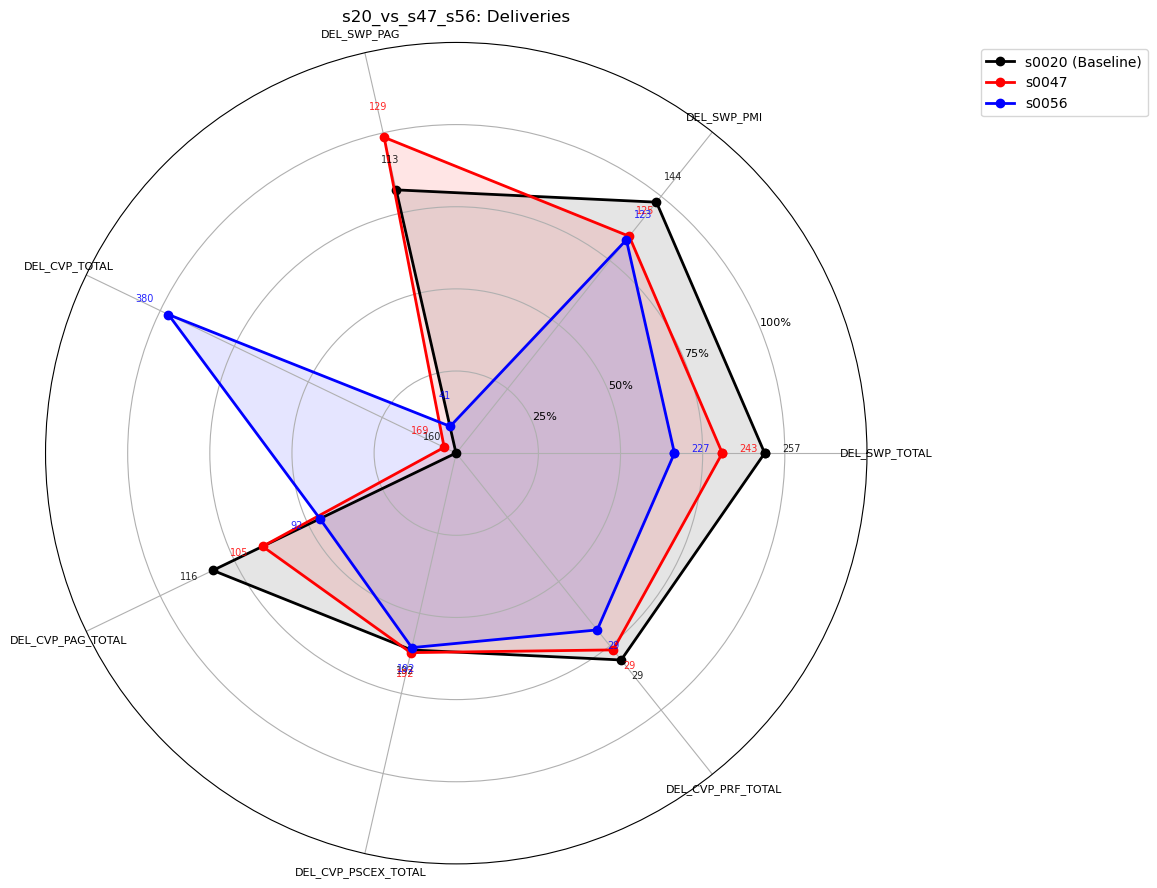

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/radar_s20_vs_s47_s56_Salinity_X2.png


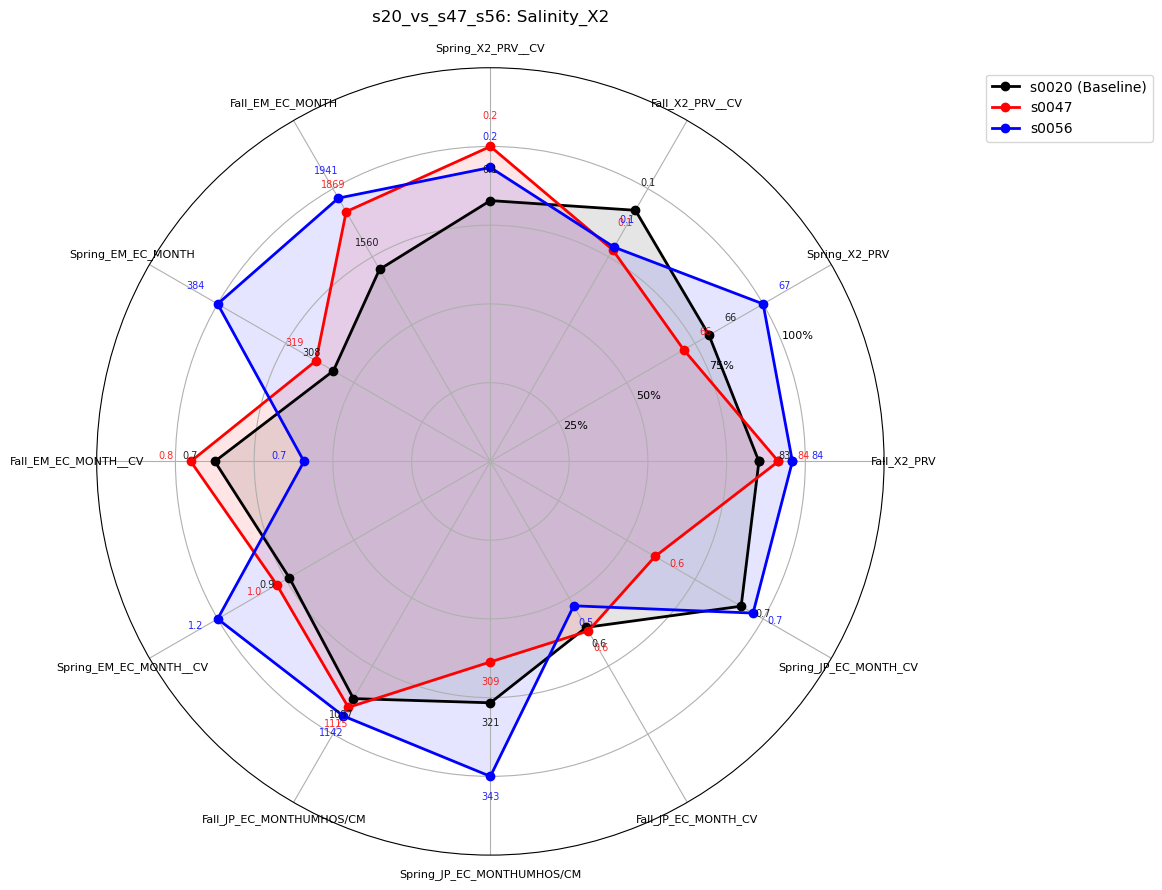

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/radar_s27_vs_s62_s63_Storage_Apr.png


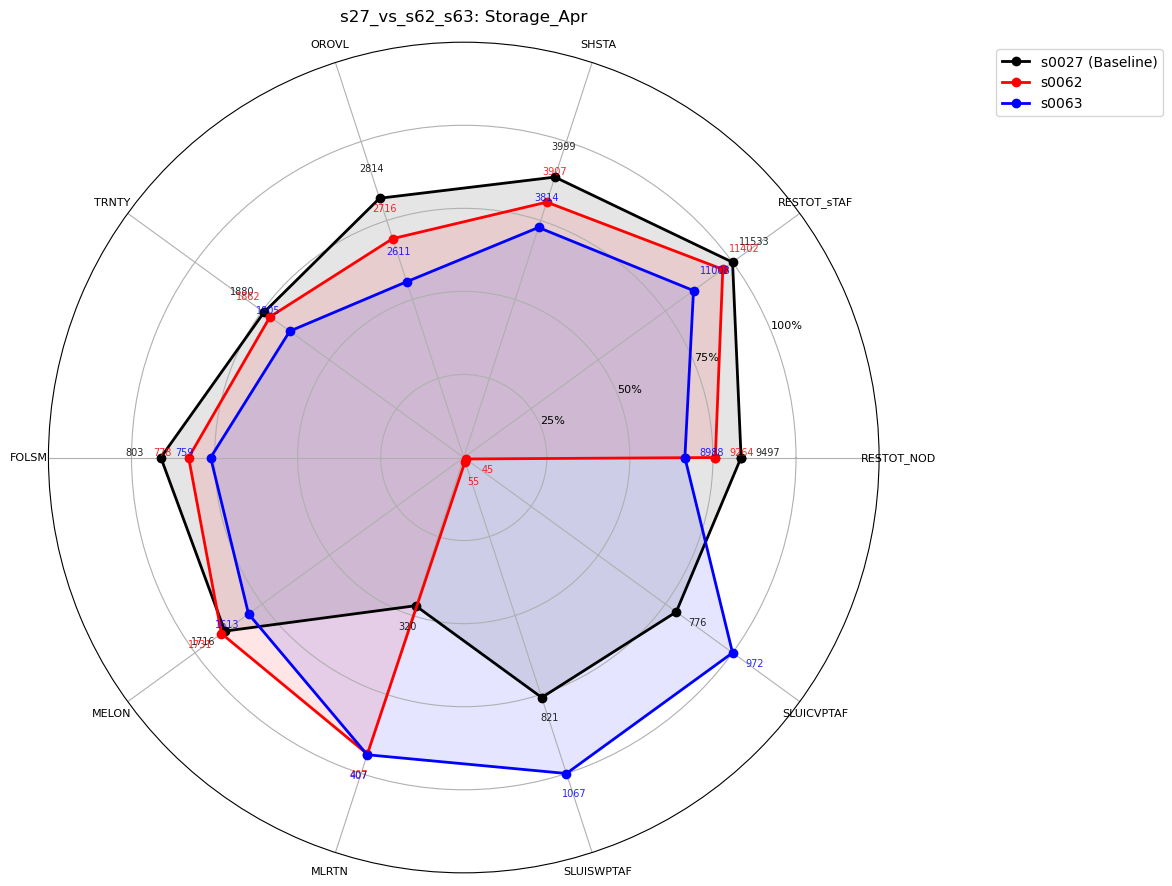

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/radar_s27_vs_s62_s63_Deliveries.png


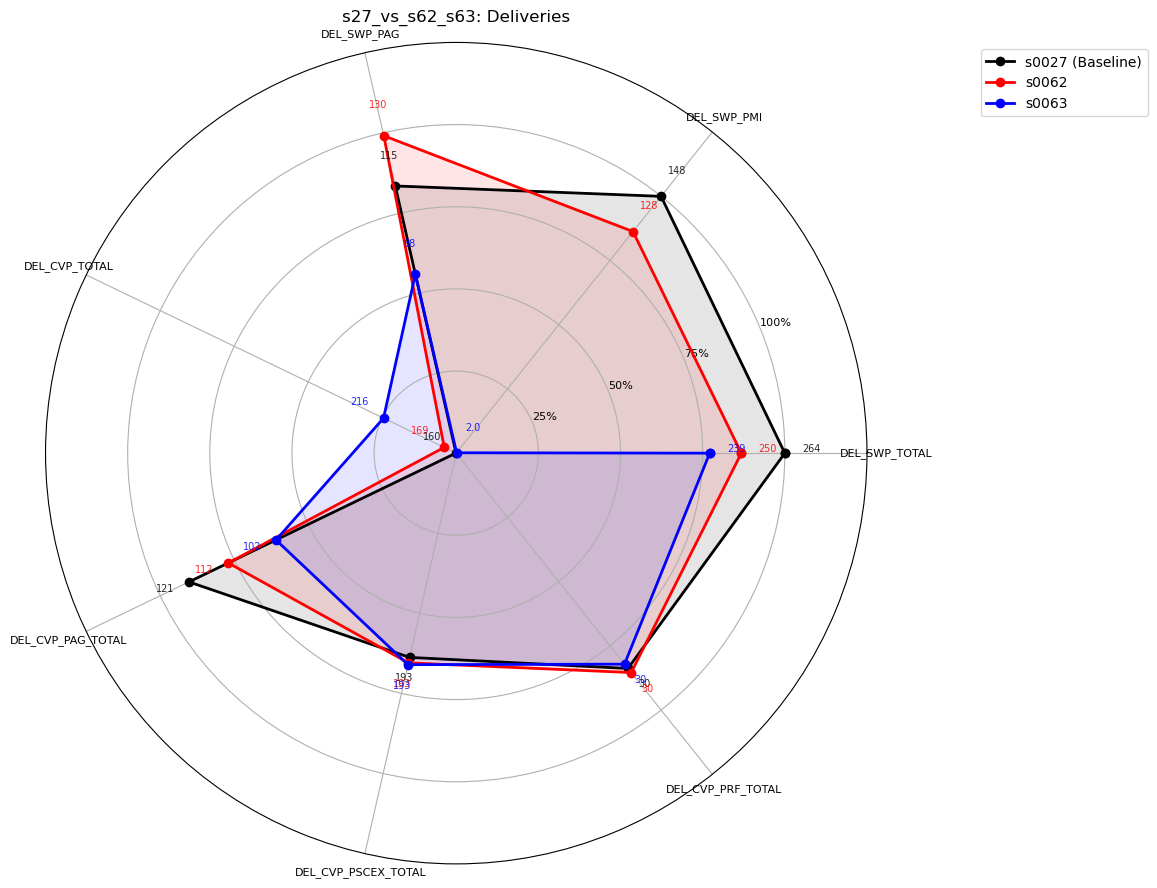

Saved: ../../CalSim3_Model_Runs/Scenarios/Group_Data_Extraction/metrics_output/new_plotting/radar_s27_vs_s62_s63_Salinity_X2.png


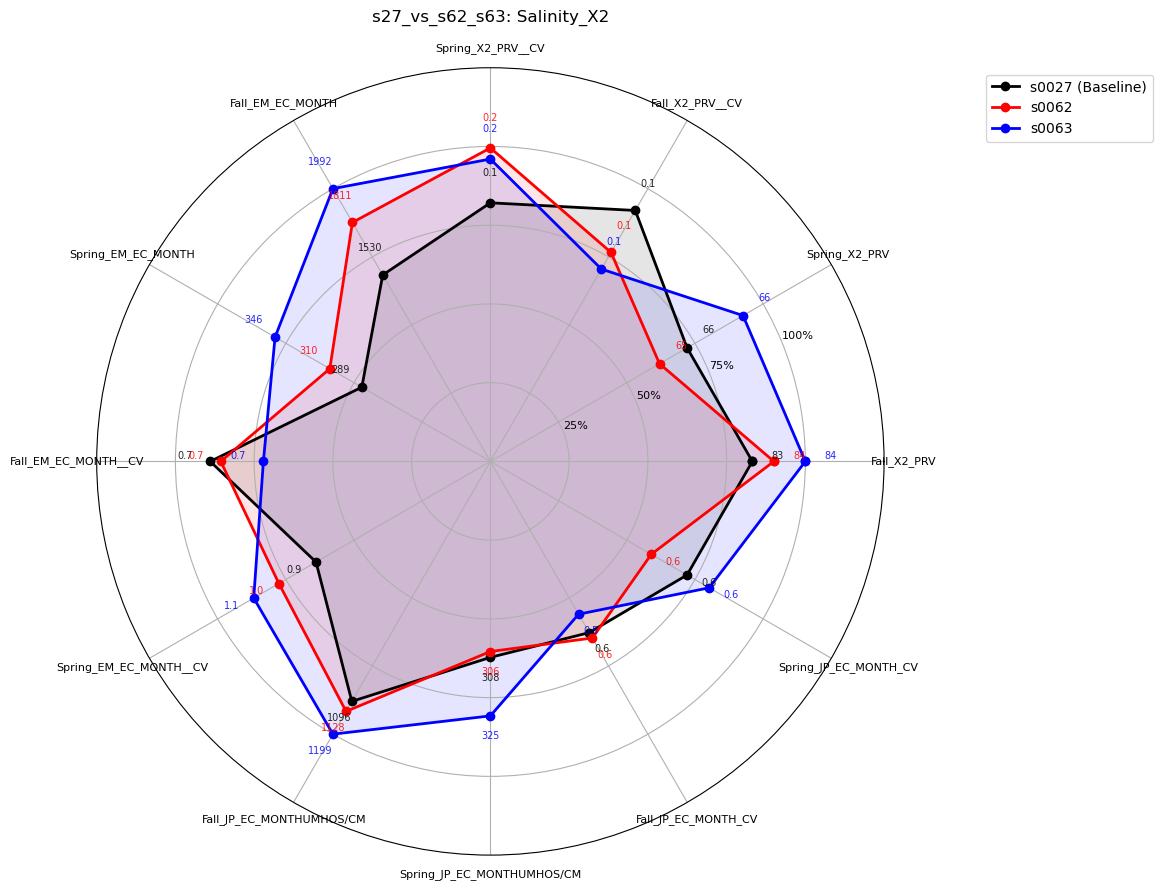

In [7]:
for sset in SCENARIO_SETS:
    for grp, cols in METRIC_GROUPS.items():
        save_path = os.path.join(OUT_DIR, f"radar_{sset['name']}_{grp}.png")
        plot_radar(df, cols, sset['all_ids'], sset['colors'], sset['labels'], 
                   f"{sset['name']}: {grp}", save_path=save_path)